In [1]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFE
from sklearn.cluster import KMeans
from sklearn.calibration import CalibratedClassifierCV
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTEENN
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Cell 2: Load the dataset
df = pd.read_excel('combined_finals_with_attendance.xlsx', sheet_name='Sheet1')
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (301, 22)


,Has_Failure_Before_Sem5,Internal_Avg_Sem1,Internal_Avg_Sem2,Internal_Avg_Sem3,Internal_Avg_Sem4,Internal_Avg_Sem5,SGPA_Sem1,SGPA_Sem2,SGPA_Sem3,SGPA_Sem4,...,branch,hosteller,regno,CGPA,Ext_Avg_Sem1,Ext_Avg_Sem2,Ext_Avg_Sem3,Ext_Avg_Sem4,Ext_Avg_Sem5,Absent Percentage (%)
0,0,36.521739,36.68,46.000000,39.000000,47.000000,7.0435,7.56,6.6818,7.6000,...,Chemical Engineering,Day Scholar,127006043,7.42252,66.086957,77.20,68.000000,62.000000,66.000000,15.89
1,1,33.434783,31.96,28.941176,31.882353,31.636364,5.6522,6.00,6.4286,5.0476,...,Chemical Engineering,Hosteler,127002023,5.85296,53.739130,57.84,69.647059,47.764706,60.909091,9.66
2,1,25.521739,24.20,24.647059,31.352941,32.681818,4.1304,4.32,4.0000,4.0000,...,Chemical Engineering,Day Scholar,127002046,4.05372,45.826087,52.64,47.529412,31.882353,34.636364,6.23
3,1,28.608696,31.48,33.235294,33.352941,33.590909,5.4783,6.64,6.5714,5.2381,...,Chemical Engineering,Day Scholar,127002038,6.16738,54.956522,70.16,67.647059,44.588235,71.000000,12.11
4,1,32.434783,29.32,26.411765,34.235294,31.181818,5.8696,5.36,4.9524,6.2857,...,Chemical Engineering,Hosteler,127002055,5.11172,54.956522,55.20,52.117647,59.058824,29.272727,22.49


In [3]:
# Cell 3+4: Function to build features and target for a given target semester
def build_features_and_target(df, target_sem, threshold=61):
    """
    Build X (features) and y (risk) for a given target semester.
    - target_sem: integer (2,3,4,5,...)
    - risk = 1 if Ext_Avg_Sem{target_sem} <= threshold else 0
    - Features include internal averages up to target_sem, external up to target_sem-1,
      plus trends, gaps, rolling stats, weighted averages, etc.
    """
    # Drop unnecessary columns
    df = df.drop(['regno', 'CGPA'], axis=1, errors='ignore')
    sgpa_cols = [f'SGPA_Sem{i}' for i in range(1,6)]
    df = df.drop([c for c in sgpa_cols if c in df.columns], axis=1, errors='ignore')

    # Map hosteller
    df['hosteller'] = (df['hosteller'] == 'Hosteler').astype(int)

    # One-hot encode categoricals
    df = pd.get_dummies(df, columns=['admission_category', 'branch'], drop_first=True)

    # Rename target column if present
    if 'Has_Failure_Before_Sem5' in df.columns:
        df.rename(columns={'Has_Failure_Before_Sem5': 'arrears'}, inplace=True)

    # Define risk based on target semester's external average
    ext_col = f'Ext_Avg_Sem{target_sem}'
    if ext_col not in df.columns:
        raise ValueError(f"Column {ext_col} not found. Cannot define risk for semester {target_sem}.")
    df['risk'] = (df[ext_col] <= threshold).astype(int)

    # Base numeric columns: internal up to target_sem, external up to target_sem-1
    internal_cols = [f'Internal_Avg_Sem{i}' for i in range(1, target_sem+1)]
    external_cols = [f'Ext_Avg_Sem{i}' for i in range(1, target_sem)]
    other_cols = ['arrears', 'hosteller', 'Absent Percentage (%)']
    cat_cols = [col for col in df.columns if col.startswith('admission_category_') or col.startswith('branch_')]

    numeric_cols = internal_cols + external_cols + other_cols + cat_cols
    numeric_cols = [col for col in numeric_cols if col in df.columns]

    X_base = df[numeric_cols].copy()
    y = df['risk']

    # Impute missing values with median
    imputer = SimpleImputer(strategy='median')
    X_imputed = imputer.fit_transform(X_base)
    X_base = pd.DataFrame(X_imputed, columns=numeric_cols, index=df.index)

    # ---- Dynamic Feature Engineering ----
    # Trend features (internal)
    for sem in range(2, target_sem+1):
        X_base[f'Internal_trend_Sem{sem}'] = X_base[f'Internal_Avg_Sem{sem}'] - X_base[f'Internal_Avg_Sem{sem-1}']

    # Trend features (external) – only if at least 2 external semesters exist
    if target_sem >= 3:
        for sem in range(2, target_sem):
            X_base[f'Ext_trend_Sem{sem}'] = X_base[f'Ext_Avg_Sem{sem}'] - X_base[f'Ext_Avg_Sem{sem-1}']

    # Gap features (internal - external) for semesters where both exist
    for sem in range(1, target_sem):
        if f'Ext_Avg_Sem{sem}' in X_base.columns:
            X_base[f'Int_Ext_gap_Sem{sem}'] = X_base[f'Internal_Avg_Sem{sem}'] - X_base[f'Ext_Avg_Sem{sem}']

    # Rolling statistics (window=2) for internal averages
    for sem in range(3, target_sem+1):
        X_base[f'Internal_roll2_Sem{sem}'] = (X_base[f'Internal_Avg_Sem{sem-1}'] + X_base[f'Internal_Avg_Sem{sem}']) / 2
        X_base[f'Internal_std_Sem{sem-1}_{sem}'] = X_base[[f'Internal_Avg_Sem{sem-1}', f'Internal_Avg_Sem{sem}']].std(axis=1)

    # Weighted averages (uniform weights for simplicity)
    # Weighted Internal
    num = den = 0
    for sem in range(1, target_sem+1):
        w = 1
        num += w * X_base[f'Internal_Avg_Sem{sem}']
        den += w
    X_base['Weighted_Internal'] = num / den

    # Weighted External (only if we have at least one external semester)
    if target_sem >= 2:
        num = den = 0
        for sem in range(1, target_sem):
            w = 1
            num += w * X_base[f'Ext_Avg_Sem{sem}']
            den += w
        X_base['Weighted_External'] = num / den

    # Ratio features (Internal / External)
    for sem in range(1, target_sem):
        if f'Ext_Avg_Sem{sem}' in X_base.columns:
            X_base[f'Int_Ext_ratio_Sem{sem}'] = X_base[f'Internal_Avg_Sem{sem}'] / (X_base[f'Ext_Avg_Sem{sem}'] + 1e-5)

    # Interactions with arrears and absent
    X_base['arrears_x_Weighted_Internal'] = X_base['arrears'] * X_base['Weighted_Internal']
    X_base['arrears_x_Absent'] = X_base['arrears'] * X_base['Absent Percentage (%)']

    # Absent bins
    bins = [0,5,10,15,20,25,100]
    labels = [f'absent_{i}_{j}' for i,j in zip(bins[:-1], bins[1:])]
    X_base['Absent_Bin'] = pd.cut(X_base['Absent Percentage (%)'], bins=bins, labels=labels)
    absent_dummies = pd.get_dummies(X_base['Absent_Bin'], prefix='absent_bin')
    X_base = pd.concat([X_base, absent_dummies], axis=1)
    for col in absent_dummies.columns:
        X_base[f'{col}_x_Weighted_Internal'] = X_base[col] * X_base['Weighted_Internal']
        if 'Weighted_External' in X_base.columns:
            X_base[f'{col}_x_Weighted_External'] = X_base[col] * X_base['Weighted_External']
    X_base.drop('Absent_Bin', axis=1, inplace=True)

    # Clustering of student trajectories
    traj_cols = [f'Internal_Avg_Sem{i}' for i in range(1, target_sem+1)]
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    X_base['trajectory_cluster'] = kmeans.fit_predict(X_base[traj_cols])

    # Drop constant columns
    X = X_base.loc[:, X_base.var() > 1e-10]
    return X, y, kmeans, imputer

In [4]:
# Cell 5: Build features for a specific semester and select top features
TARGET_SEMESTER = 4  # <-- CHANGE THIS to 2,3,4,5 as needed
THRESHOLD = 61

X, y, kmeans, imputer = build_features_and_target(df, TARGET_SEMESTER, THRESHOLD)

# Feature selection using RFE
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rfe = RFE(estimator=rf_selector, n_features_to_select=25, step=2)
X_selected = rfe.fit_transform(X, y)
selected_features = X.columns[rfe.support_]
X = pd.DataFrame(X_selected, columns=selected_features, index=X.index)
print("Selected features:", X.shape[1])
print("Features used:", list(X.columns))

Selected features: 25
Features used: ['Internal_Avg_Sem1', 'Internal_Avg_Sem2', 'Internal_Avg_Sem3', 'Internal_Avg_Sem4', 'Ext_Avg_Sem1', 'Ext_Avg_Sem2', 'Ext_Avg_Sem3', 'arrears', 'Absent Percentage (%)', 'Internal_trend_Sem2', 'Internal_trend_Sem3', 'Ext_trend_Sem3', 'Int_Ext_gap_Sem1', 'Int_Ext_gap_Sem2', 'Int_Ext_gap_Sem3', 'Internal_roll2_Sem3', 'Internal_std_Sem2_3', 'Internal_roll2_Sem4', 'Internal_std_Sem3_4', 'Weighted_Internal', 'Weighted_External', 'Int_Ext_ratio_Sem2', 'Int_Ext_ratio_Sem3', 'arrears_x_Absent', 'absent_bin_absent_15_20_x_Weighted_External']


In [5]:
# Cell 6: Cross‑validation setup
cv_outer = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [6]:
# Cell 7: Base learners and hyperparameter grids (unchanged)
base_models = {
    'lr': LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    'rf': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'xgb': xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42,
                              scale_pos_weight=(len(y)-sum(y))/sum(y)),
    'lgb': lgb.LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1)
}

param_grids = {
    'lr': {'classifier__C': [0.01, 0.1, 1, 10, 100]},
    'rf': {'classifier__n_estimators': [100, 300, 500],
           'classifier__max_depth': [5, 10, None],
           'classifier__min_samples_split': [2, 5, 10]},
    'xgb': {'classifier__learning_rate': [0.01, 0.05, 0.1, 0.3],
            'classifier__max_depth': [3, 5, 7],
            'classifier__subsample': [0.7, 0.8, 1.0],
            'classifier__colsample_bytree': [0.7, 0.8, 1.0]},
    'lgb': {'classifier__num_leaves': [31, 50, 70],
            'classifier__learning_rate': [0.01, 0.05, 0.1],
            'classifier__n_estimators': [100, 300]}
}

In [7]:
# Cell 8: Hyperparameter tuning for each base model
best_estimators = {}
for name, model in base_models.items():
    print(f"\nTuning {name}...")
    pipeline = ImbPipeline([
        ('smoteenn', SMOTEENN(random_state=42)),
        ('scaler', StandardScaler()),
        ('classifier', model)
    ])
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    search = RandomizedSearchCV(pipeline, param_grids[name], cv=inner_cv,
                                scoring='f1', n_iter=20, random_state=42, n_jobs=-1)
    search.fit(X, y)
    best_estimators[name] = search.best_estimator_
    print(f"Best {name} CV F1: {search.best_score_:.4f}")




Tuning lr...
Best lr CV F1: 0.8200

Tuning rf...
Best rf CV F1: 0.8381

Tuning xgb...
Best xgb CV F1: 0.8244

Tuning lgb...
Best lgb CV F1: 0.8283


In [8]:
# Cell 9: Stacking ensemble with meta‑learner and calibration
meta_xgb = xgb.XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=4,
                             use_label_encoder=False, eval_metric='logloss',
                             random_state=42, scale_pos_weight=(len(y)-sum(y))/sum(y))
meta_pipeline = Pipeline([('scaler', StandardScaler()), ('clf', meta_xgb)])

stacking_clf = StackingClassifier(
    estimators=[(name, best_estimators[name]) for name in base_models.keys()],
    final_estimator=meta_pipeline,
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1
)

calibrated_stacking = CalibratedClassifierCV(stacking_clf, method='sigmoid', cv=3)


In [9]:
# Cell 10: Evaluate stacking using 10‑fold CV with per‑fold threshold tuning
thresholds = np.arange(0.1, 0.9, 0.01)
y_proba_all = np.zeros(len(y))
y_pred_all = np.zeros(len(y))
best_thresholds = []

for train_idx, val_idx in cv_outer.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    stacking_temp = StackingClassifier(
        estimators=[(name, best_estimators[name]) for name in base_models.keys()],
        final_estimator=meta_pipeline,
        cv=5,
        stack_method='predict_proba',
        n_jobs=-1
    )
    stacking_temp.fit(X_train, y_train)
    proba_val = stacking_temp.predict_proba(X_val)[:,1]

    best_f1 = 0
    best_thresh = 0.5
    for thresh in thresholds:
        pred_thresh = (proba_val >= thresh).astype(int)
        f1_val = f1_score(y_val, pred_thresh)
        if f1_val > best_f1:
            best_f1 = f1_val
            best_thresh = thresh

    y_proba_all[val_idx] = proba_val
    y_pred_all[val_idx] = (proba_val >= best_thresh).astype(int)
    best_thresholds.append(best_thresh)

final_acc = accuracy_score(y, y_pred_all)
final_f1 = f1_score(y, y_pred_all)
final_auc = roc_auc_score(y, y_proba_all)

print("\n" + "="*50)
print(f"RESULTS FOR SEMESTER {TARGET_SEMESTER}")
print("="*50)
print(f"Accuracy: {final_acc:.4f}")
print(f"F1 Score: {final_f1:.4f}")
print(f"AUC: {final_auc:.4f}")
print(f"Mean optimal threshold: {np.mean(best_thresholds):.2f}")


RESULTS FOR SEMESTER 4
Accuracy: 0.9369
F1 Score: 0.8774
AUC: 0.9484
Mean optimal threshold: 0.33


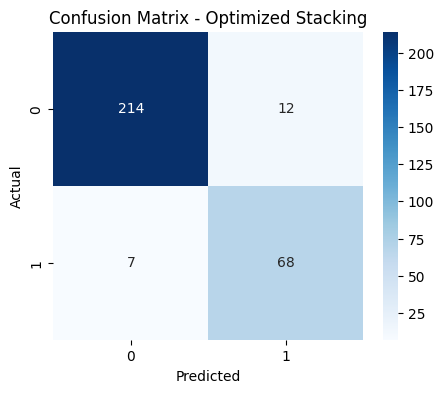

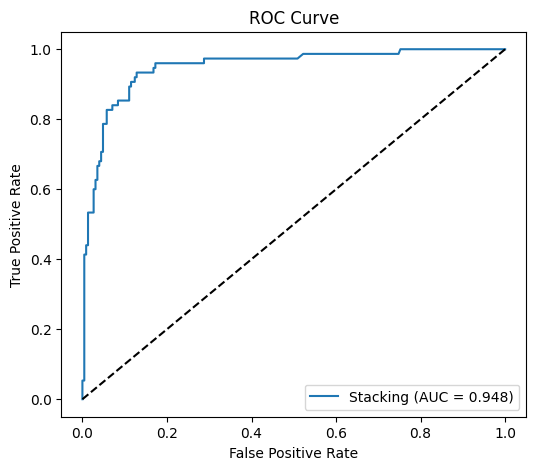

In [10]:
# Cell 11: Confusion Matrix and ROC Curve
cm = confusion_matrix(y, y_pred_all)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Optimized Stacking')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

fpr, tpr, _ = roc_curve(y, y_proba_all)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'Stacking (AUC = {final_auc:.3f})')
plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

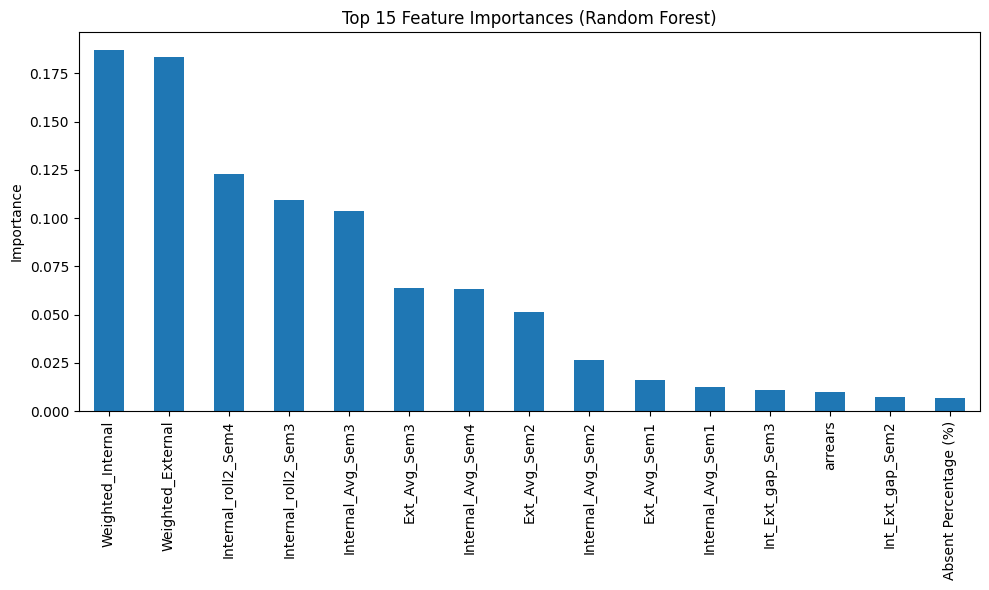

In [11]:
# Cell 12: Feature importance from the tuned Random Forest
rf_best = best_estimators['rf'].named_steps['classifier']
importances = rf_best.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
feat_imp.head(15).plot(kind='bar')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

In [12]:
# Cell 13: Summary of enhancements and results
print("\n" + "="*60)
print("SUMMARY OF ENHANCEMENTS")
print("="*60)
print(f"Target semester: {TARGET_SEMESTER}")
print(f"Risk threshold: Ext_Avg_Sem{TARGET_SEMESTER} < {THRESHOLD}")
print(f"Final feature count: {X.shape[1]} (selected from {X.shape[1]})")
print(f"Dataset size: {X.shape[0]} samples")
print(f"Best F1 Score: {final_f1:.4f}")
print(f"Best Accuracy: {final_acc:.4f}")
print(f"Mean threshold: {np.mean(best_thresholds):.2f}")


SUMMARY OF ENHANCEMENTS
Target semester: 4
Risk threshold: Ext_Avg_Sem4 < 61
Final feature count: 25 (selected from 25)
Dataset size: 301 samples
Best F1 Score: 0.8774
Best Accuracy: 0.9369
Mean threshold: 0.33


In [13]:
# Cell 14: Save fitted objects for the chosen semester (including base columns)
import joblib

# Get the best Random Forest model from stacking
rf_model = best_estimators['rf'].named_steps['classifier']

# Refit scaler on the final feature matrix X (after feature selection)
scaler_final = StandardScaler().fit(X)

# Rebuild the base data (before feature engineering) to capture the exact column names
X_base_temp, _, _, _ = build_features_and_target(df, TARGET_SEMESTER, THRESHOLD)
base_columns = X_base_temp.columns.tolist()

# Save all objects
joblib.dump(rf_model, f'risk_rf_model_sem{TARGET_SEMESTER}.pkl')
joblib.dump(imputer, f'imputer_sem{TARGET_SEMESTER}.pkl')
joblib.dump(scaler_final, f'scaler_sem{TARGET_SEMESTER}.pkl')
joblib.dump(selected_features.tolist(), f'feature_names_sem{TARGET_SEMESTER}.pkl')
joblib.dump(kmeans, f'kmeans_model_sem{TARGET_SEMESTER}.pkl')
joblib.dump(base_columns, f'base_columns_sem{TARGET_SEMESTER}.pkl')

print(f"Models and base columns saved for semester {TARGET_SEMESTER}.")

Models and base columns saved for semester 4.


In [14]:
# Load ML model and preprocessing objects
rf_model = joblib.load(f'risk_rf_model_sem{TARGET_SEMESTER}.pkl')
imputer_ml = joblib.load(f'imputer_sem{TARGET_SEMESTER}.pkl')
scaler_ml = joblib.load(f'scaler_sem{TARGET_SEMESTER}.pkl')
feature_names_ml = joblib.load(f'feature_names_sem{TARGET_SEMESTER}.pkl')
kmeans_ml = joblib.load(f'kmeans_model_sem{TARGET_SEMESTER}.pkl')
base_columns_ml = joblib.load(f'base_columns_sem{TARGET_SEMESTER}.pkl')

📈 Internal marks: 26.43 → 27.81 (Δ = +1.37)
📈 External marks: 48.00 → 18.29 (Δ = -29.71)
📐 Improvement ratio (External Δ / Internal Δ): -21.61



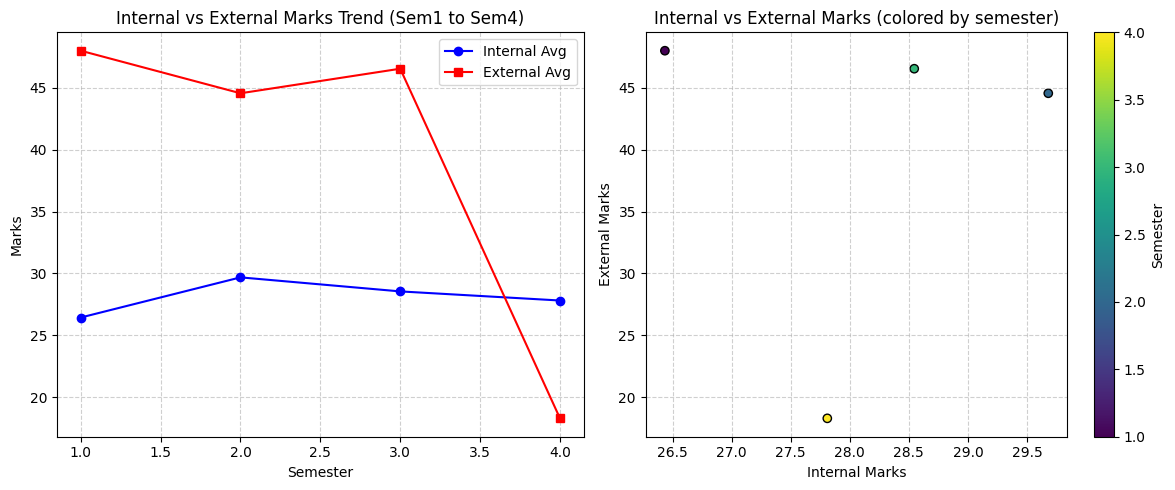

In [16]:
# Cell 15: Plot internal vs external mark trends (up to target semester)

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load raw data
df_raw = pd.read_excel('combined_finals_with_attendance.xlsx', sheet_name='Sheet1')
student_row = df_raw[df_raw['regno'].astype(str) == str(regno)]

if not student_row.empty:
    internal_cols = [f'Internal_Avg_Sem{i}' for i in range(1, TARGET_SEMESTER+1) if f'Internal_Avg_Sem{i}' in student_row.columns]
    external_cols = [f'Ext_Avg_Sem{i}' for i in range(1, TARGET_SEMESTER+1) if f'Ext_Avg_Sem{i}' in student_row.columns]

    if internal_cols and external_cols:
        semesters = list(range(1, TARGET_SEMESTER+1))
        internal_vals = [student_row[col].values[0] for col in internal_cols]
        external_vals = [student_row[col].values[0] for col in external_cols]

        # Calculate improvement metrics
        internal_improve = internal_vals[-1] - internal_vals[0]
        external_improve = external_vals[-1] - external_vals[0]
        ratio = external_improve / internal_improve if internal_improve != 0 else float('inf')

        print(f"📈 Internal marks: {internal_vals[0]:.2f} → {internal_vals[-1]:.2f} (Δ = {internal_improve:+.2f})")
        print(f"📈 External marks: {external_vals[0]:.2f} → {external_vals[-1]:.2f} (Δ = {external_improve:+.2f})")
        print(f"📐 Improvement ratio (External Δ / Internal Δ): {ratio:.2f}\n")

        # Plot 1: Line graph
        plt.figure(figsize=(12,5))
        plt.subplot(1,2,1)
        plt.plot(semesters, internal_vals, marker='o', label='Internal Avg', color='blue')
        plt.plot(semesters, external_vals, marker='s', label='External Avg', color='red')
        plt.xlabel('Semester')
        plt.ylabel('Marks')
        plt.title(f'Internal vs External Marks Trend (Sem1 to Sem{TARGET_SEMESTER})')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.6)

        # Plot 2: Scatter plot
        plt.subplot(1,2,2)
        sc = plt.scatter(internal_vals, external_vals, c=semesters, cmap='viridis', edgecolors='k')
        plt.colorbar(sc, label='Semester')
        plt.xlabel('Internal Marks')
        plt.ylabel('External Marks')
        plt.title('Internal vs External Marks (colored by semester)')
        plt.grid(True, linestyle='--', alpha=0.6)

        plt.tight_layout()
        plt.show()
    else:
        print("Insufficient data for trend plot.")
else:
    print(f"Student {regno} not found.")

In [17]:
# Cell 16: Generate full report with tabular trend and simple recommendation (no z‑scores)

# ============================================================
# Enhanced rule‑based report with tabular trend and basic recommendation
# ============================================================
def generate_rule_based_report_enhanced(regno, avg_point, weak_subjects, weak_prereqs,
                                        prob_risk, target_sem, internal_vals, external_vals,
                                        internal_improve, external_improve):
    risk_level = "HIGH" if prob_risk >= 0.5 else "LOW"
    weak_count = len(weak_subjects)
    prereq_weak_count = len(weak_prereqs)

    lines = []
    lines.append("=" * 70)
    lines.append(f"ACADEMIC REPORT FOR STUDENT {regno} (Rule‑Based) - Semester {target_sem}")
    lines.append("=" * 70)
    lines.append(f"\n📊 Model Risk Probability: {prob_risk:.2%} ({risk_level} risk)")
    lines.append(f"📈 Overall Average Grade Point (Semesters 1-4): {avg_point:.2f}")

    # ----- Tabular trend (internal and external averages) -----
    lines.append("\n📊 **PERFORMANCE TREND (Semester-wise Averages)**")
    lines.append("📌 Note: External marks are out of 100 (percentage).")
    lines.append("-" * 60)
    lines.append(f"{'Semester':<10} {'Internal Avg':<15} {'External Avg':<15} {'Δ Internal':<12} {'Δ External':<12}")
    lines.append("-" * 60)
    prev_int = internal_vals[0]
    prev_ext = external_vals[0]
    for i, (int_val, ext_val) in enumerate(zip(internal_vals, external_vals), start=1):
        delta_int = int_val - prev_int if i > 1 else 0
        delta_ext = ext_val - prev_ext if i > 1 else 0
        lines.append(f"Semester {i:<5} {int_val:<15.2f} {ext_val:<15.2f} {delta_int:+12.2f} {delta_ext:+12.2f}")
        prev_int, prev_ext = int_val, ext_val
    lines.append("-" * 60)

    # ----- Simple recommendation (no z‑scores) -----
    recommendation = ""
    if internal_improve > 0 and external_improve > 0:
        recommendation = "✅ Both internal and external marks improved. Keep up the good work!"
    elif internal_improve > 0 and external_improve <= 0:
        recommendation = "⚠️ Internal marks improved, but external marks did not. Focus on exam preparation (timed practice, past papers)."
    elif internal_improve <= 0 and external_improve > 0:
        recommendation = "⚠️ External marks improved, but internal consistency dropped. Strengthen coursework and assignments."
    else:
        recommendation = "⚠️ Both internal and external marks declined. Seek academic support and form study groups."

    lines.append(f"\n💡 **KEY RECOMMENDATION:** {recommendation}")
    lines.append("-" * 60)

    # ----- Weak subjects list -----
    if weak_subjects:
        lines.append("\n⚠️ WEAK SUBJECTS (Grade D/E/F):")
        for course, pt in weak_subjects:
            lines.append(f"   • {course} (point {pt})")

    # ----- Prerequisite weaknesses -----
    if weak_prereqs:
        lines.append(f"\n🔸 PREREQUISITE WEAKNESSES AFFECTING SEMESTER {target_sem}:")
        for course, prereq, pt, sem in weak_prereqs:
            lines.append(f"   • {course} requires {prereq} (Sem {sem}, point {pt}) – below average/weak.")
    else:
        lines.append("\n✅ No critical prerequisite weaknesses detected.")

    lines.append("\n📌 GENERIC RECOMMENDATIONS:")
    lines.append("   • Review weak subjects and prerequisite topics before focusing on current courses.")
    lines.append("   • Seek extra help or tutoring for foundational gaps.")
    lines.append("   • Use past exam papers and mock tests to improve.")
    lines.append("=" * 70)
    return "\n".join(lines)

# ============================================================
# Modified main report generation (no z‑scores, shows table with scale note)
# ============================================================
def generate_report_with_numeric_suggestions(regno, target_sem, threshold=61):
    # Load raw dataset for trend data
    df_raw = pd.read_excel('combined_finals_with_attendance.xlsx', sheet_name='Sheet1')
    student_row = df_raw[df_raw['regno'].astype(str) == str(regno)]
    if student_row.empty:
        return f"Student with regno {regno} not found in combined_finals_with_attendance.xlsx"

    # Extract student's internal and external values (Sem1 to target_sem)
    internal_cols = [f'Internal_Avg_Sem{i}' for i in range(1, target_sem+1) if f'Internal_Avg_Sem{i}' in student_row.columns]
    external_cols = [f'Ext_Avg_Sem{i}' for i in range(1, target_sem+1) if f'Ext_Avg_Sem{i}' in student_row.columns]
    if internal_cols and external_cols:
        internal_vals = [student_row[col].values[0] for col in internal_cols]
        external_vals = [student_row[col].values[0] for col in external_cols]
        internal_improve = internal_vals[-1] - internal_vals[0]
        external_improve = external_vals[-1] - external_vals[0]
    else:
        internal_vals = external_vals = []
        internal_improve = external_improve = 0

    # Get grade data (same as before)
    grade_dict, sem_dict, avg_point, semester_grades, target_courses = get_student_data(regno, target_sem)
    if grade_dict is None:
        return f"Student {regno} not found in semester_wise_subjects_final.xlsx"

    weak_subjects = [(c, pt) for c, pt in grade_dict.items() if pt < 6]

    # Prerequisite weaknesses
    course_weak_prereqs = {}
    for course in target_courses:
        prereqs = prerequisite_map.get(course, [])
        weak_for_course = []
        for prereq in prereqs:
            prereq_norm = normalize_course_name(prereq)
            if prereq_norm in grade_dict and grade_dict[prereq_norm] < avg_point:
                weak_for_course.append((prereq_norm, grade_dict[prereq_norm], sem_dict.get(prereq_norm, '?')))
        course_weak_prereqs[course] = weak_for_course

    all_prereqs = set()
    for course in target_courses:
        for prereq in prerequisite_map.get(course, []):
            all_prereqs.add(normalize_course_name(prereq))

    prob_risk = 0.5  # placeholder
    weak_prereqs_flat = [(c, p, pt, s) for c, lst in course_weak_prereqs.items() for p, pt, s in lst]

    # Use enhanced rule‑based report with table and simple recommendation (no z‑scores)
    narrative = generate_rule_based_report_enhanced(regno, avg_point, weak_subjects, weak_prereqs_flat,
                                                    prob_risk, target_sem, internal_vals, external_vals,
                                                    internal_improve, external_improve)

    # Subject‑wise detailed analysis (unchanged from original)
    lines = []
    lines.append("\n" + "=" * 80)
    lines.append(f"📚 SUBJECT‑WISE DETAILED ANALYSIS (Semester {target_sem} Focus)")
    lines.append("=" * 80)
    lines.append(f"\n📈 Overall Average Grade Point (Semesters 1-4): {avg_point:.2f}")
    lines.append("\n📚 ALL SUBJECTS AND GRADE POINTS (Semesters 1-4):")
    for sem in range(1,5):
        lines.append(f"\n   Semester {sem}:")
        if semester_grades[sem]:
            for course, pt in sorted(semester_grades[sem]):
                lines.append(f"      • {course}: {pt}")
        else:
            lines.append("      • (No subjects found)")
    if weak_subjects:
        lines.append("\n⚠️ WEAK SUBJECTS (Grade D/E/F) – Absolute Weakness:")
        for course, pt in weak_subjects:
            lines.append(f"   • {course} (point {pt})")
    else:
        lines.append("\n✅ No absolute weak subjects (grade D/E/F).")
    if all_prereqs:
        lines.append(f"\n🔍 PREREQUISITE SUBJECTS FOR SEMESTER {target_sem} COURSES (overview):")
        for prereq in sorted(all_prereqs):
            if prereq in grade_dict:
                pt = grade_dict[prereq]
                sem = sem_dict.get(prereq, '?')
                if pt < avg_point:
                    lines.append(f"   ⚠️ {prereq} (Sem {sem}) – grade point = {pt} (BELOW average {avg_point:.2f})")
                else:
                    lines.append(f"   ✅ {prereq} (Sem {sem}) – grade point = {pt} (at or above average)")
            else:
                lines.append(f"   ❓ {prereq} – NOT FOUND in student's records")
    else:
        lines.append(f"\n🔍 No prerequisites defined for semester {target_sem} courses.")
    lines.append(f"\n🔸 DETAILED TOPICS FOR WEAK PREREQUISITES (By Semester {target_sem} Course):")
    has_weak = False
    for course in target_courses:
        weak_list = course_weak_prereqs.get(course, [])
        if weak_list:
            has_weak = True
            lines.append(f"\n📘 {course}")
            for prereq, pt, sem in weak_list:
                lines.append(f"   ⚠️ Requires {prereq} (Semester {sem}, grade point = {pt})")
                topics = get_topics_from_llm(prereq, syllabus_text)
                if topics:
                    lines.append("      Topics to revise:")
                    for topic in topics[:6]:
                        lines.append(f"         • {topic}")
                else:
                    lines.append("      (No specific topics extracted – review entire subject)")
    if not has_weak:
        lines.append("\n✅ No prerequisite weaknesses relative to student's average.")
    lines.append("\n" + "=" * 80)
    subject_wise = "\n".join(lines)

    return narrative + "\n\n" + subject_wise

# Generate and print the enhanced report
report_with_numbers = generate_report_with_numeric_suggestions(regno, TARGET_SEMESTER, THRESHOLD)
print(report_with_numbers)

ACADEMIC REPORT FOR STUDENT 127003194 (Rule‑Based) - Semester 4

📊 Model Risk Probability: 50.00% (HIGH risk)
📈 Overall Average Grade Point (Semesters 1-4): 4.41

📊 **PERFORMANCE TREND (Semester-wise Averages)**
📌 Note: External marks are out of 100 (percentage).
------------------------------------------------------------
Semester   Internal Avg    External Avg    Δ Internal   Δ External  
------------------------------------------------------------
Semester 1     26.43           48.00                  +0.00        +0.00
Semester 2     29.68           44.56                  +3.25        -3.44
Semester 3     28.55           46.55                  -1.13        +1.99
Semester 4     27.81           18.29                  -0.74       -28.26
------------------------------------------------------------

💡 **KEY RECOMMENDATION:** ⚠️ Internal marks improved, but external marks did not. Focus on exam preparation (timed practice, past papers).
----------------------------------------------------